In [ ]:
from scripts.classification import make_classification_df, run_binary_logistic_model, modify_classification_df, evaluate_logistic_model
from scripts.classification_graphs import confusion_graph, comparison_graph
import matplotlib.pyplot as plt

In [ ]:
df = make_classification_df()

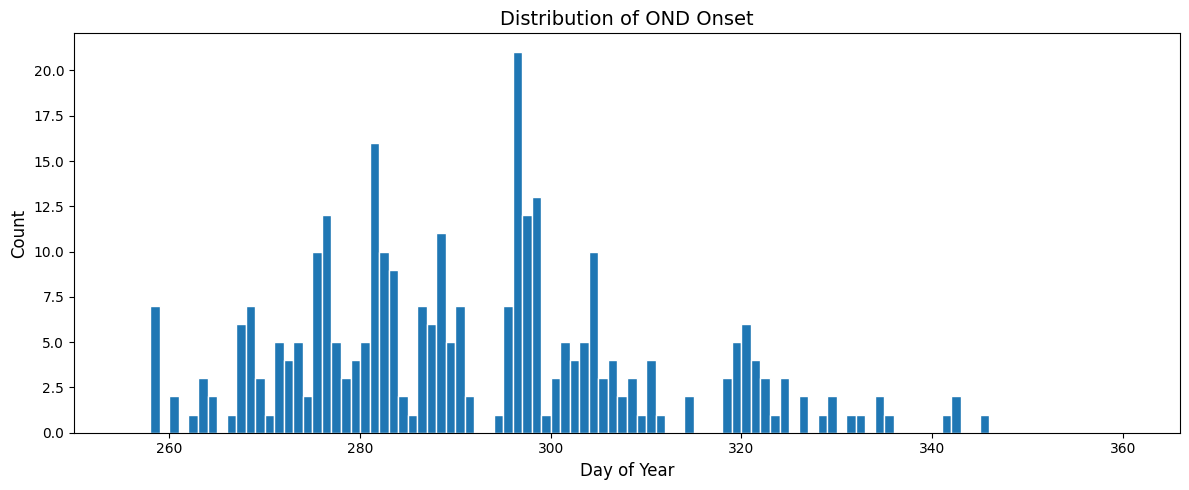

In [35]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df[df["year"] < 2021]["ond_onset"], bins=116, range=(250, 366), edgecolor="white")
ax.set_xlim(250, 366)
ax.set_xlabel("Day of Year", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Distribution of OND Onset", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
test_df, train_df = modify_classification_df(df)
train_df

281.0
297.0


,year,lat,lon,ond_onset,aug_sst_dekad1,aug_sst_dekad2,aug_sst_dekad3,aug_sm_dekad1,aug_sm_dekad2,aug_sm_dekad3,...,sep_10u_dekad1,sep_10v_dekad1,sep_2t_dekad1,sep_2d_dekad1,sep_cape_dekad1,sep_tcc_dekad1,category,early_binary,normal_binary,late_binary
0,2016,0,37,321.0,25.758461,25.976295,25.932539,0.228731,0.167427,0.184908,...,-2.918201,6.183882,288.000000,282.588348,2.734798,0.532103,Late,0,0,1
1,2016,0,38,319.0,25.758461,25.976295,25.932539,0.125633,0.127328,0.119901,...,-2.918201,6.183882,294.002289,285.747253,1.520085,0.534394,Late,0,0,1
2,2016,0,39,319.0,25.758461,25.976295,25.932539,0.097402,0.102149,0.097898,...,-2.918201,6.183882,298.474243,288.751526,1.104329,0.529933,Late,0,0,1
3,2016,0,40,319.0,25.758461,25.976295,25.932539,0.070866,0.078187,0.072828,...,-2.918201,6.183882,299.391937,290.245544,2.784635,0.559831,Late,0,0,1
4,2016,0,41,319.0,25.758461,25.976295,25.932539,0.088641,0.096710,0.094879,...,-2.918201,6.183882,299.985321,291.000732,2.741862,0.494783,Late,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300,2020,6,42,303.0,25.942032,25.799162,26.026871,0.134081,0.151074,0.133474,...,-0.729767,5.568068,300.862549,286.886261,0.869076,0.508993,Late,0,0,1
301,2020,6,44,297.0,25.942032,25.799162,26.026871,0.108710,0.107161,0.112633,...,-0.729767,5.568068,302.301605,287.106750,0.976302,0.450084,Normal,0,1,0
302,2020,6,45,304.0,25.942032,25.799162,26.026871,0.093839,0.081031,0.095349,...,-0.729767,5.568068,301.758118,287.371765,1.272494,0.476901,Late,0,0,1
303,2020,6,47,296.0,25.942032,25.799162,26.026871,0.063046,0.064740,0.065582,...,-0.729767,5.568068,301.824310,289.130920,1.227962,0.529857,Normal,0,1,0


In [39]:
model_early = run_binary_logistic_model(train_df, test_df, [
                     "aug_sm_dekad1", "lat", "lon", 
                     "sep_sst_dekad1", "sep_precip_dekad1", "aug_rzsm_dekad1", 
                     "aug_sst_dekad1", "aug_sst_dekad2", "aug_sst_dekad3", 
                     "aug_precip_dekad1", "aug_precip_dekad2", "aug_precip_dekad3", 
                     "aug_rzsm_dekad2", "aug_rzsm_dekad3", "sep_rzsm_dekad1", "sep_tcwv_dekad1", 
                        "sep_msl_dekad1", "sep_10u_dekad1", "sep_10v_dekad1", 
                        "sep_2t_dekad1", "sep_2d_dekad1", "sep_cape_dekad1", "sep_tcc_dekad1"], "early_binary")
model_early_test_df = model_early["test_df"].copy()
model_early_test_df["test_predictions"] = model_early["test_predictions"]
model_early_test_df.head()

/global/homes/s/sohailm/.conda/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/global/homes/s/sohailm/.conda/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/global/homes/s/sohailm/.conda/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.

,aug_sm_dekad1,lat,lon,sep_sst_dekad1,sep_precip_dekad1,aug_rzsm_dekad1,aug_sst_dekad1,aug_sst_dekad2,aug_sst_dekad3,aug_precip_dekad1,...,sep_tcwv_dekad1,sep_msl_dekad1,sep_10u_dekad1,sep_10v_dekad1,sep_2t_dekad1,sep_2d_dekad1,sep_cape_dekad1,sep_tcc_dekad1,early_binary,test_predictions
305,0.165334,0,37,26.288122,0.677255,0.267940,25.976824,26.11574,26.156958,0.925280,...,34.81768,101399.695312,-2.956316,5.896349,289.222748,284.682922,24.385937,0.688840,0,0
306,0.140087,0,38,26.288122,0.033000,0.212430,25.976824,26.11574,26.156958,0.057345,...,34.81768,101399.695312,-2.956316,5.896349,295.600433,287.090881,6.230404,0.619848,0,0
307,0.100150,0,39,26.288122,0.000000,0.142078,25.976824,26.11574,26.156958,0.000000,...,34.81768,101399.695312,-2.956316,5.896349,300.133240,289.820374,2.016536,0.560729,0,0
308,0.075278,0,40,26.288122,0.086905,0.138906,25.976824,26.11574,26.156958,0.004685,...,34.81768,101399.695312,-2.956316,5.896349,300.620300,291.581665,5.601498,0.621107,0,0
309,0.113124,0,41,26.288122,0.648030,0.137861,25.976824,26.11574,26.156958,0.111720,...,34.81768,101399.695312,-2.956316,5.896349,300.926331,292.476501,6.101172,0.580264,0,0


=== BASIC METRICS ===
Accuracy:  0.8667
F1 Score:  0.3750
Precision: 0.3333
Recall:    0.4286
ROC AUC:   0.7983

=== CONFUSION MATRIX ===
[[62  6]
 [ 4  3]]

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.94      0.91      0.93        68
           1       0.33      0.43      0.38         7

    accuracy                           0.87        75
   macro avg       0.64      0.67      0.65        75
weighted avg       0.88      0.87      0.87        75



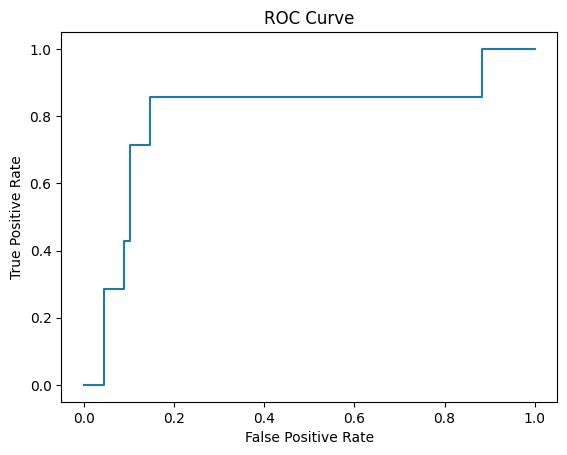

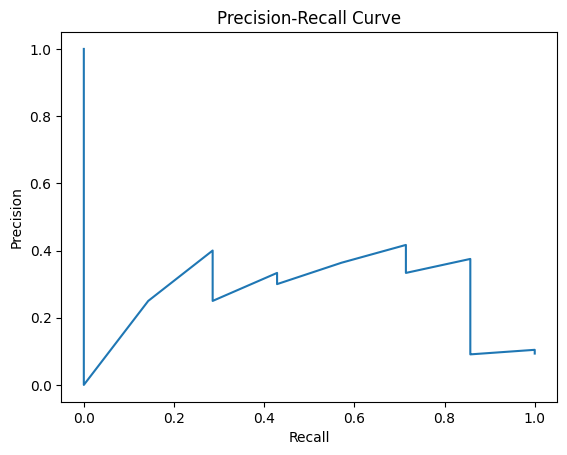


=== LASSO SPARSITY ===
Total features: 23
Zero coefficients: 15
Sparsity: 65.22%

=== TOP FEATURES ===
              feature      coef
15    sep_rzsm_dekad1  2.878126
1                 lat  1.129711
0     sep_tcwv_dekad1  1.111309
18  aug_precip_dekad3  1.074116
3      sep_10v_dekad1 -0.989530
22      sep_2t_dekad1  0.982966
21      sep_2d_dekad1 -0.267669
17    aug_rzsm_dekad2  0.000051
5      sep_tcc_dekad1  0.000000
4      sep_sst_dekad1  0.000000
2       aug_sm_dekad1  0.000000
6     sep_cape_dekad1  0.000000
7      sep_10u_dekad1  0.000000
9   sep_precip_dekad1  0.000000
8     aug_rzsm_dekad1  0.000000
14     aug_sst_dekad3  0.000000
13  aug_precip_dekad1  0.000000
12     aug_sst_dekad2  0.000000
11     aug_sst_dekad1  0.000000
10                lon  0.000000
16    aug_rzsm_dekad3  0.000000
20     sep_msl_dekad1  0.000000
19  aug_precip_dekad2  0.000000


In [40]:
evaluate_logistic_model(model_early)

In [41]:
model_normal = run_binary_logistic_model(train_df, test_df, [
                     "aug_sm_dekad1", "lat", "lon", 
                     "sep_sst_dekad1", "sep_precip_dekad1", "aug_rzsm_dekad1", 
                     "aug_sst_dekad1", "aug_sst_dekad2", "aug_sst_dekad3", 
                     "aug_precip_dekad1", "aug_precip_dekad2", "aug_precip_dekad3", 
                     "aug_rzsm_dekad2", "aug_rzsm_dekad3", "sep_rzsm_dekad1", "sep_tcwv_dekad1", 
                        "sep_msl_dekad1", "sep_10u_dekad1", "sep_10v_dekad1", 
                        "sep_2t_dekad1", "sep_2d_dekad1", "sep_cape_dekad1", "sep_tcc_dekad1"], "normal_binary")
model_normal_test_df = model_normal["test_df"].copy()
model_normal_test_df["test_predictions"] = model_normal["test_predictions"]
model_normal_test_df.head()

/global/homes/s/sohailm/.conda/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/global/homes/s/sohailm/.conda/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/global/homes/s/sohailm/.conda/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.

,aug_sm_dekad1,lat,lon,sep_sst_dekad1,sep_precip_dekad1,aug_rzsm_dekad1,aug_sst_dekad1,aug_sst_dekad2,aug_sst_dekad3,aug_precip_dekad1,...,sep_tcwv_dekad1,sep_msl_dekad1,sep_10u_dekad1,sep_10v_dekad1,sep_2t_dekad1,sep_2d_dekad1,sep_cape_dekad1,sep_tcc_dekad1,normal_binary,test_predictions
305,0.165334,0,37,26.288122,0.677255,0.267940,25.976824,26.11574,26.156958,0.925280,...,34.81768,101399.695312,-2.956316,5.896349,289.222748,284.682922,24.385937,0.688840,0,1
306,0.140087,0,38,26.288122,0.033000,0.212430,25.976824,26.11574,26.156958,0.057345,...,34.81768,101399.695312,-2.956316,5.896349,295.600433,287.090881,6.230404,0.619848,0,1
307,0.100150,0,39,26.288122,0.000000,0.142078,25.976824,26.11574,26.156958,0.000000,...,34.81768,101399.695312,-2.956316,5.896349,300.133240,289.820374,2.016536,0.560729,0,1
308,0.075278,0,40,26.288122,0.086905,0.138906,25.976824,26.11574,26.156958,0.004685,...,34.81768,101399.695312,-2.956316,5.896349,300.620300,291.581665,5.601498,0.621107,0,1
309,0.113124,0,41,26.288122,0.648030,0.137861,25.976824,26.11574,26.156958,0.111720,...,34.81768,101399.695312,-2.956316,5.896349,300.926331,292.476501,6.101172,0.580264,0,1


=== BASIC METRICS ===
Accuracy:  0.4800
F1 Score:  0.5185
Precision: 0.3889
Recall:    0.7778
ROC AUC:   0.5147

=== CONFUSION MATRIX ===
[[15 33]
 [ 6 21]]

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.71      0.31      0.43        48
           1       0.39      0.78      0.52        27

    accuracy                           0.48        75
   macro avg       0.55      0.55      0.48        75
weighted avg       0.60      0.48      0.46        75



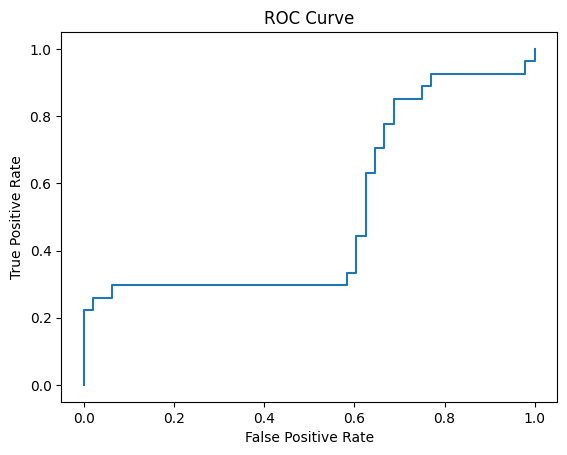

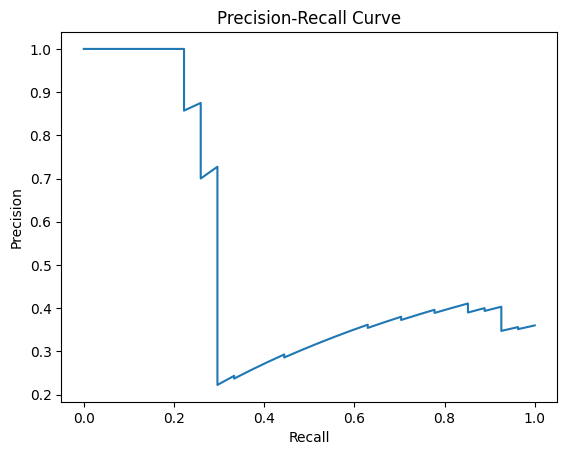


=== LASSO SPARSITY ===
Total features: 23
Zero coefficients: 7
Sparsity: 30.43%

=== TOP FEATURES ===
              feature      coef
15      sep_2d_dekad1 -2.867715
3     sep_cape_dekad1  2.171496
18  aug_precip_dekad1 -1.551198
21    aug_rzsm_dekad2  0.963673
11      aug_sm_dekad1 -0.947452
10     aug_sst_dekad2 -0.912305
2      sep_10v_dekad1  0.827609
19     aug_sst_dekad3 -0.824784
1      sep_sst_dekad1  0.472224
22     sep_msl_dekad1 -0.455086
7       sep_2t_dekad1  0.416985
0     sep_tcwv_dekad1 -0.335359
4   aug_precip_dekad3  0.260694
17    sep_rzsm_dekad1 -0.203911
5   aug_precip_dekad2 -0.008161
20    aug_rzsm_dekad3  0.005784
6                 lon  0.000000
14    aug_rzsm_dekad1  0.000000
9      sep_tcc_dekad1  0.000000
8                 lat  0.000000
13     sep_10u_dekad1  0.000000
12  sep_precip_dekad1  0.000000
16     aug_sst_dekad1  0.000000


In [42]:
evaluate_logistic_model(model_normal, "normal_binary")

In [43]:
model_late = run_binary_logistic_model(train_df, test_df, [
                     "aug_sm_dekad1", "lat", "lon", 
                     "sep_sst_dekad1", "sep_precip_dekad1", "aug_rzsm_dekad1", 
                     "aug_sst_dekad1", "aug_sst_dekad2", "aug_sst_dekad3", 
                     "aug_precip_dekad1", "aug_precip_dekad2", "aug_precip_dekad3", 
                     "aug_rzsm_dekad2", "aug_rzsm_dekad3", "sep_rzsm_dekad1", "sep_tcwv_dekad1", 
                        "sep_msl_dekad1", "sep_10u_dekad1", "sep_10v_dekad1", 
                        "sep_2t_dekad1", "sep_2d_dekad1", "sep_cape_dekad1", "sep_tcc_dekad1"], "late_binary")
model_late_test_df = model_late["test_df"].copy()
model_late_test_df["test_predictions"] = model_late["test_predictions"]
model_late_test_df.head()

/global/homes/s/sohailm/.conda/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/global/homes/s/sohailm/.conda/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/global/homes/s/sohailm/.conda/envs/myenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.

,aug_sm_dekad1,lat,lon,sep_sst_dekad1,sep_precip_dekad1,aug_rzsm_dekad1,aug_sst_dekad1,aug_sst_dekad2,aug_sst_dekad3,aug_precip_dekad1,...,sep_tcwv_dekad1,sep_msl_dekad1,sep_10u_dekad1,sep_10v_dekad1,sep_2t_dekad1,sep_2d_dekad1,sep_cape_dekad1,sep_tcc_dekad1,late_binary,test_predictions
305,0.165334,0,37,26.288122,0.677255,0.267940,25.976824,26.11574,26.156958,0.925280,...,34.81768,101399.695312,-2.956316,5.896349,289.222748,284.682922,24.385937,0.688840,1,1
306,0.140087,0,38,26.288122,0.033000,0.212430,25.976824,26.11574,26.156958,0.057345,...,34.81768,101399.695312,-2.956316,5.896349,295.600433,287.090881,6.230404,0.619848,1,1
307,0.100150,0,39,26.288122,0.000000,0.142078,25.976824,26.11574,26.156958,0.000000,...,34.81768,101399.695312,-2.956316,5.896349,300.133240,289.820374,2.016536,0.560729,1,1
308,0.075278,0,40,26.288122,0.086905,0.138906,25.976824,26.11574,26.156958,0.004685,...,34.81768,101399.695312,-2.956316,5.896349,300.620300,291.581665,5.601498,0.621107,1,1
309,0.113124,0,41,26.288122,0.648030,0.137861,25.976824,26.11574,26.156958,0.111720,...,34.81768,101399.695312,-2.956316,5.896349,300.926331,292.476501,6.101172,0.580264,1,1


=== BASIC METRICS ===
Accuracy:  0.6400
F1 Score:  0.7523
Precision: 0.6029
Recall:    1.0000
ROC AUC:   0.8565

=== CONFUSION MATRIX ===
[[ 7 27]
 [ 0 41]]

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       1.00      0.21      0.34        34
           1       0.60      1.00      0.75        41

    accuracy                           0.64        75
   macro avg       0.80      0.60      0.55        75
weighted avg       0.78      0.64      0.57        75



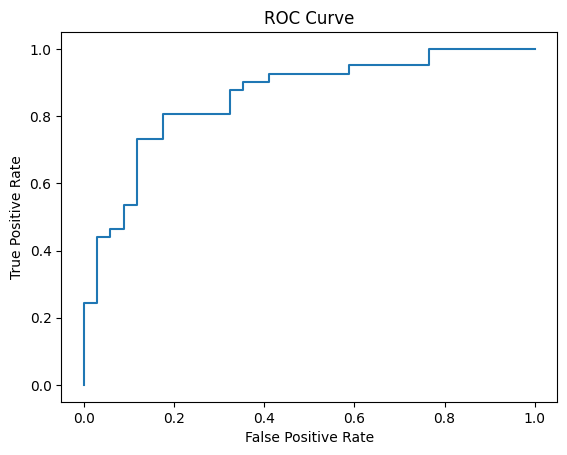

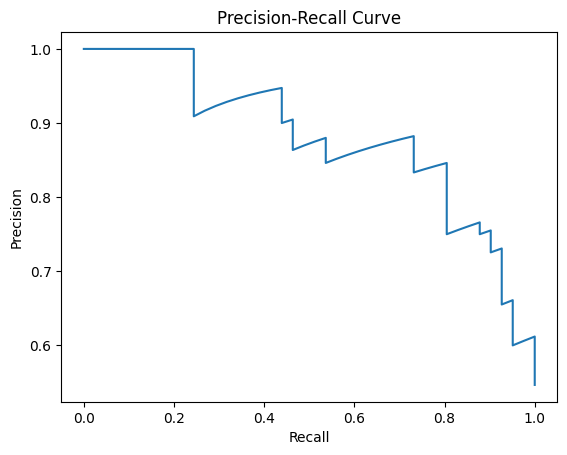


=== LASSO SPARSITY ===
Total features: 23
Zero coefficients: 0
Sparsity: 0.00%

=== TOP FEATURES ===
              feature       coef
5                 lat  10.872718
14     aug_sst_dekad1  -8.105781
15                lon  -5.880479
3      sep_sst_dekad1   2.953097
13  aug_precip_dekad3  -2.714027
1     sep_rzsm_dekad1  -2.553573
18     sep_tcc_dekad1  -2.028953
20     aug_sst_dekad3  -1.772781
10      sep_2t_dekad1   1.223009
0     aug_rzsm_dekad1  -1.196808
19    aug_rzsm_dekad2   1.191124
7       sep_2d_dekad1   0.866724
16    sep_cape_dekad1  -0.710089
11     aug_sst_dekad2  -0.695153
6      sep_10v_dekad1  -0.684639
2     sep_tcwv_dekad1   0.525784
21     sep_10u_dekad1   0.406262
9       aug_sm_dekad1  -0.357832
22  sep_precip_dekad1  -0.345772
12     sep_msl_dekad1  -0.332203
8   aug_precip_dekad2  -0.324953
17  aug_precip_dekad1  -0.130760
4     aug_rzsm_dekad3  -0.113546


In [44]:
evaluate_logistic_model(model_late, "late_binary")

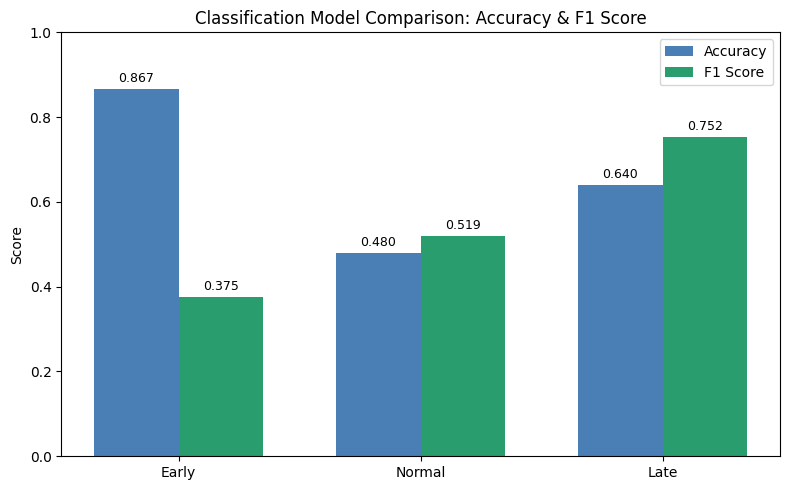

In [ ]:
comparison_graph(model_early, model_normal, model_late)

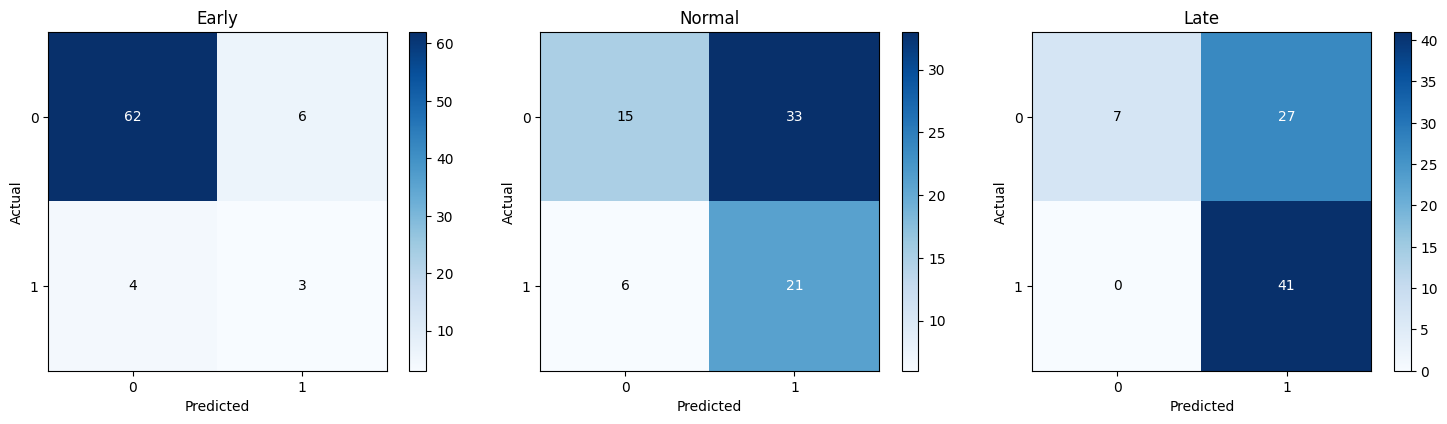

In [ ]:
confusion_graph(model_early, model_normal, model_late)